<a href="https://colab.research.google.com/github/kaushikpatriot/ML-Projects/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns ; sns.set() # for plot styling

from scipy.spatial.distance import cdist
from sklearn.datasets import make_blobs

In [ ]:
cluster_count = 3

(100, 2)


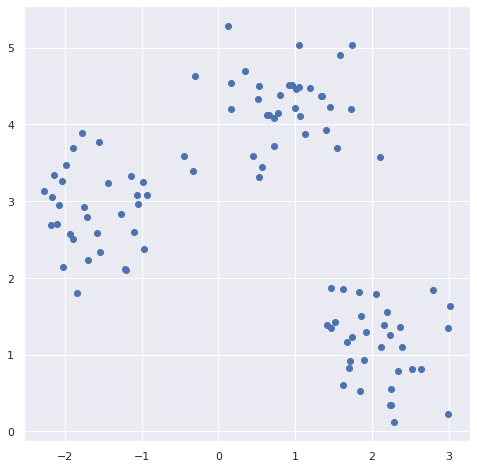

In [ ]:
X, y = make_blobs(n_samples = 100, centers = cluster_count, cluster_std = 0.5, n_features = 2, random_state = 0)
print(X.shape)

plt.figure(figsize =(8,8))
plt.scatter(X[:,0],X[:,1])

In [ ]:
def fit(X,k):
  #initialise centroids
  centroids = X[np.random.randint(0,X.shape[0],size=k)]

  #calculate initial label for each point
  labels = np.argmin(cdist(X,centroids), axis=1)

  for i in range(10):
    previous_labels = labels.copy()

    #compute new centroids
    centroids = np.array([np.mean(X[labels==r], axis = 0) for r in range(k)])

    #recalculate labels
    labels = np.argmin(cdist(X,centroids), axis = 1)

    # Check for exit
    if all(labels == previous_labels):
      break

  return centroids, labels

In [ ]:
centroids, labels = fit(X, cluster_count)

[2 0 2 0 0 0 1 1 2 0 0 0 2 0 1 2 1 0 1 1 1 1 1 0 2 2 2 2 1 1 0 2 2 0 1 1 0
 2 2 1 1 2 2 0 0 0 2 2 1 1 1 2 0 2 1 1 2 2 0 2 2 1 1 1 1 2 0 1 2 0 1 2 0 2
 2 2 0 0 1 2 0 0 2 0 2 0 0 0 2 0 2 2 1 1 1 1 0 0 1 1]


In [ ]:
print("Centroids:", centroids)

Centroids: [[-1.55605149  2.90230638]
 [ 0.91471566  4.26637114]
 [ 2.09729671  1.12471414]]


In [ ]:
def plot_kmeans(X, centroids, labels, rseed=0, ax = None):
  #plot the input data
  ax = ax or plt.gca()
  ax.axis('equal')

  #plot data points
  ax.scatter(X[:,0], X[:,1], c=labels, s = 40, cmap = 'plasma', zorder=2)

  #plot the representation of the Kmeans model
  radii = [cdist(X[labels==i],[center]).max() for i, center in enumerate(centroids)]
  for c,r in zip (centroids, radii):
    ax.add_patch(plt.Circle(c,r, fc='#CCCCCC', lw=5,alpha = 0.5, zorder=1))

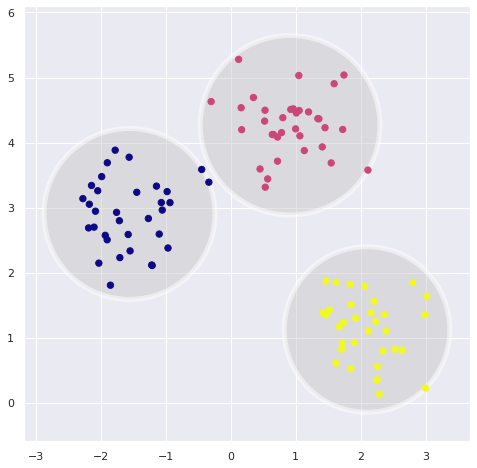

In [ ]:
plt.figure(figsize =(8,8))
plot_kmeans(X, centroids, labels)